# NASCAR Tire Falloff Analysis

### NASCAR Cup Series — Next Gen Era (2022–Current)

This notebook uses `pynascar` race and telemetry data to calculate and visualize tire falloff for a selected driver and track.

## Imports and Installs

In [3]:
# Install PyNASCAR if needed
# !pip install pynascar

In [4]:
# Imports
import pandas as pd
import numpy as np
from pynascar import Schedule, Race, set_options
from pynascar import get_settings
from pynascar.driver import DriversData
import matplotlib.pyplot as plt

# Import NASCAR track information and track lengths
track_lookup = pd.read_csv('cup_tracks.csv') # provided in the repository files

## Function 1: `race_id_locator()`

The `race_id_locator()` function searches the `pynascar` Cup Series schedule for races held at the selected track from 2022–current. It returns the race ID and basic race information needed to pull data for each available race.

In [5]:
# FUNCTION_1 Locate race_id from pynascar API
def race_id_locator(track_name):
    race_list = []

    for year in range(2022,2026):
        races = Schedule(year, 1)  # year=2026-2025, Series=Cup

        target_track = races.data[
            races.data['track_name'] == track_name]  # Filter for track
        
        race_list.append(target_track)

    race_df = pd.concat(race_list, ignore_index=True)

    # Convert race_date format
    race_df['race_date'] = pd.to_datetime(race_df['race_date']).dt.strftime('%B %d, %Y')
    return race_df[['race_id', 'race_season', 'race_name', 'track_name', 'race_date']]

## Function 2: `pull_races()`

The `pull_races()` function uses the race IDs identified in Function 1 to retrieve the full `pynascar` race data for each event. Each race is stored in a dictionary using its race ID, allowing the race data to be accessed and analyzed individually.

In [6]:
# FUNCTION_2 Pull race data
def pull_races(race_info):
    races = {}
    for _, row in race_info.iterrows():
        year = row['race_season']
        race_id = row['race_id']
        race = Race(year, 1, race_id, reload=True)

        races[race_id] = race

    return races

## Function 3: `prep_driver_data()`

The `prep_driver_data()` function prepares the selected driver's lap and pit-stop data for each race. It calculates lap times using track length and lap speed, identifies green-flag and caution periods, tracks tire changes, and calculates tire age based on the number of green-flag laps completed on each tire set.

The prepared data is stored separately for each race and is used to create the tire falloff visualizations.

In [7]:
# FUNCTION_3 
def prep_driver_data(races, race_info, driver_name, track_name):

    # Find track in lookup table
    track_row = track_lookup[
        (track_lookup['lr_track_name'] == track_name) |
        (track_lookup['rr_track_name'] == track_name) |
        (track_lookup['Alias'] == track_name)]

    # Get track length
    track_length = track_row['length_miles'].values[0] # Extract track length as a single value


    # create DFs from .telemetry.lap_times & .telemetry.pit_stops
    # Store finished driver DataFrames for each race
    driver_data = {} 

    for race_id, race in races.items():

        driver_speed = race.telemetry.lap_times[
            race.telemetry.lap_times['driver_name']==driver_name].copy()
        
        # Convert lap_speed to lap time (in seconds)
        driver_speed['lap_time'] = ((track_length / driver_speed['lap_speed'])*3600).round(3)

        driver_pit = race.telemetry.pit_stops[
            race.telemetry.pit_stops['driver_name']==driver_name].copy()


    
        # ID Stage Breaks / Cautions in the Race
        # Create driver_speed['race_status']
        driver_speed['race_status'] = 'green'

        # Loop through each caution to add stage breaks
        for _, caution in race.results.cautions.iterrows():
            start = caution['start_lap']
            end = caution['end_lap']

            # Determine the type of caution it is
            if (caution['caution_type'] == 'Competition'
            and 'Stage' in caution['comment']):
                status = 'stage_break'
            else:
                status = 'caution'
            # Assign status to every lap in caution range
            driver_speed.loc[driver_speed['Lap'].between(start,end), 'race_status'] = status



        # Create tire_age column
        # Create List of laps where driver_name pitted
        tire_change_laps = [0] # Start with Lap 0 for the initial tire set

        # Find tire-change laps from pit data
        pit_tire_changes = driver_pit.loc[ # row_condition, column -> selection
            (driver_pit['pit_stop_type'] == 'FOUR_WHEEL_CHANGE') |
            (driver_pit['pit_stop_type'] == 'TWO_WHEEL_CHANGE_RIGHT'), 'lap'  # Revise to treat TWO_WHEEL tire changes
        ].to_list()  

        # Add those laps to tire_change_laps list
        tire_change_laps.extend(pit_tire_changes)

        # Create ['last_tire_change'] column
        driver_speed['last_tire_change'] = driver_speed['Lap'].where(driver_speed['Lap'].isin(tire_change_laps)).ffill()

        # Create tire_age using cumulative sum .cumsum()
        # Count green flag laps
        driver_speed['green_lap'] = (driver_speed['race_status']=='green').astype(int)
        #Tire Age
        driver_speed['tire_age'] = (driver_speed.groupby('last_tire_change')['green_lap'].cumsum())


        # Tag Year for each DataFrame #
        race_meta = race_info[race_info['race_id'] == race_id]

        race_year = race_meta['race_season'].values[0]
        race_name = race_meta['race_name'].values[0]
        race_date = race_meta['race_date'].values[0]

        driver_speed['race_id'] = race_id
        driver_speed['race_year'] = race_year
        driver_speed['race_name'] = race_name
        driver_speed['race_date'] = race_date
        driver_speed['track_name'] = track_name

        driver_pit['race_id'] = race_id
        driver_pit['race_year'] = race_year
        driver_pit['race_name'] = race_name
        driver_pit['race_date'] = race_date
        driver_pit['track_name'] = track_name

        # Save prepped DataFrame
        driver_data[race_id] = driver_speed

    return driver_data


## Function 4: `plot_tire_falloff_line()`
The `plot_tire_falloff_line()` function creates a tire falloff line chart for each available race. Lap times are filtered to focus on representative green-flag pace and remove abnormal laps caused by cautions, pit cycles, weather, or other non-representative conditions.

Each colored line represents an individual tire run, allowing changes in lap time to be observed as tire age increases.

In [8]:
# FUNCTION 4
# Create Line Chart Function
def plot_tire_falloff_line(driver_data, driver_name, track_name):

    plt.style.use('dark_background')

    for race_id, driver_speed in driver_data.items():

        # Skip races where dirver has no lap data
        if driver_speed.empty:
            continue

        # Use Race metadata for titling charts
        race_year = driver_speed['race_year'].iloc[0]
        race_name = driver_speed['race_name'].iloc[0]
        race_date = driver_speed['race_date'].iloc[0]


        # Filter Green-Flag Laps
        driver_green = driver_speed[
            (driver_speed['race_status']=='green') &
            (driver_speed['Lap'] > 3)]


        # Skip if no usable green laps
        if driver_green.empty:
            continue
        
        # Set chart range around median green-flag lap time
        median_lap = driver_green['lap_time'].median()
        lower_limit = median_lap - 1.5
        upper_limit = median_lap + 1.5

        # Remove abnormal lap_times
        driver_green = driver_green[driver_green['lap_time'].between(lower_limit, upper_limit)]
        tick_start = np.floor(lower_limit * 2) / 2
        tick_end = np.ceil(upper_limit * 2) / 2
        



        # Plotting
        plt.figure(figsize=(15,8))

        # Plot each tire run
        colors = plt.cm.Accent.colors
        for i, (tire_change, run) in enumerate(driver_green.groupby('last_tire_change')):

            plt.plot(
                run['tire_age'],
                run['lap_time'],
                marker='o',
                markersize=2.5,
                alpha=0.6,
                color=colors[i],
                linewidth=2,
                label=f'Run starting Lap {int(tire_change)}')



        # Format chart
        plt.xlabel('Tire Age')
        plt.ylabel('Lap Time')
        plt.grid(axis='y', alpha=0.05)
        plt.ylim(upper_limit, lower_limit)
        plt.yticks(np.arange(tick_start, tick_end + 0.2, 0.2))


        plt.title(
            f'{driver_name} Tire Fall Off\n'
            f'{race_year} {race_name} - {track_name} - {race_date}')

        plt.legend()
        plt.show()

## Function 5: `analyze_track()`

The `analyze_track()` function combines the previous helper functions into a single workflow. The user provides a track name and driver name, and the function locates the available races, retrieves the race data, prepares the driver's lap data, and generates the tire falloff visualizations.

The function also returns a summary of the driver's average and median lap times and finishing position for each available race.

In [ ]:
# FUNCTION 5
def analyze_track(track_name, driver_name):

    # Step 1: Find races at selected track
    race_info = race_id_locator(track_name)

    # Step 2: Pull race data
    races = pull_races(race_info)

    # Step 3: Prepare driver's data
    driver_data = prep_driver_data(races, race_info, driver_name, track_name)

     # Summary Results Display
    summary = []
    for race_id, race in races.items():
            
        driver_speed = driver_data[race_id]

        if driver_speed.empty:
            continue

        driver_green = driver_speed[
            (driver_speed['race_status']=='green') &
            (driver_speed['Lap'] > 3)]

        if driver_green.empty:
            continue

        median_lap = driver_green['lap_time'].median()
        lower_limit = median_lap - 2
        upper_limit = median_lap + 2

        driver_green = driver_green[driver_green['lap_time'].between(lower_limit,upper_limit)]
        avg_laptime = driver_green['lap_time'].mean()

        results = race.results.results

        driver_result = results[results['driver_name']==driver_name]

        if driver_result.empty:
            continue

        finish_pos = driver_result['finishing_position'].values[0]

        summary.append({
            'race_year': driver_speed['race_year'].iloc[0],
            'race_name': driver_speed['race_name'].iloc[0],
            'race_date': driver_speed['race_date'].iloc[0],
            'avg_laptime': round(avg_laptime, 3),
            'median_laptime': round(median_lap, 3),
            'finish_pos': finish_pos
        })

    summary_df = pd.DataFrame(summary)
    
    # Display summary
    display(summary_df)

    # Step 4: Plot Driver Data
    plot_tire_falloff_line(driver_data, driver_name, track_name)

    return summary_df

## Example Analysis

Run the completed analysis by providing a valid track name and driver name to `analyze_track()`.

The `track_name` and `driver_name` argument must match one of the track/driver names available through `pynascar` and raced between 2022 and 2025 (if you decide to keep those parameters).

*Some* examples of availibe track and driver names include:

### Example Track Names

`Bowman Gray Stadium` | `Daytona International Speedway` | `Atlanta Motor Speedway` | `Circuit of The Americas` | `Phoenix Raceway` | `Las Vegas Motor Speedway` | `Homestead-Miami Speedway` | `Martinsville Speedway` | `Darlington Raceway` | `Bristol Motor Speedway` | `Talladega Superspeedway` | `Texas Motor Speedway` | `Kansas Speedway` | `North Wilkesboro Speedway` | `Charlotte Motor Speedway` | `Nashville Superspeedway` | `Michigan International Speedway` | `Autódromo Hermanos Rodríguez` | `Pocono Raceway` | `Chicago Street Race` | `Sonoma Raceway` | `Dover Motor Speedway` | `Indianapolis Motor Speedway` | `Iowa Speedway` | `Watkins Glen International` | `Richmond Raceway` | `World Wide Technology Raceway` | `New Hampshire Motor Speedway` | `Charlotte Motor Speedway Road Course`


### Example Driver Names

`Ross Chastain` | `Austin Cindric` | `Austin Dillon` | `Noah Gragson` | `Kyle Larson` | `Brad Keselowski` | `Justin Haley` | `Kyle Busch` | `Chase Elliott` | `Ty Dillon` | `Denny Hamlin` | `Ryan Blaney` | `AJ Allmendinger` | `Chris Buescher` | `Chase Briscoe` | `Christopher Bell` | `Josh Berry` | `Joey Logano` | `Bubba Wallace` | `William Byron` | `Todd Gilliland` | `Riley Herbst` | `Zane Smith` | `Cole Custer` | `John Hunter Nemechek` | `Erik Jones` | `Tyler Reddick` | `Ricky Stenhouse Jr.` | `Alex Bowman` | `Cody Ware` | `Ty Gibbs` | `Ryan Preece` | `Michael McDowell` | `Carson Hocevar` | `Shane Van Gisbergen` | `Connor Zilisch` | `Corey Heim`

> **Note:** Driver availability will vary by race and season. Some drivers may not have competed in every Cup Series season between 2022–2025, while others may have missed individual races or joined the series as rookies during this period. The analysis will only generate results for races where data is available for the selected driver.

Fetching Data for 2022-1-5167
Fetching Data for 2023-1-5293
Fetching Data for 2024-1-5412
Fetching Data for 2025-1-5567


,race_year,race_name,race_date,avg_laptime,median_laptime,finish_pos
0,2022,Ambetter 301,"July 17, 2022",31.550,31.481,15
1,2023,Crayon 301,"July 17, 2023",31.803,31.815,10
2,2024,USA TODAY 301,"June 23, 2024",31.741,31.742,2
3,2025,Mobil 1 301,"September 21, 2025",30.933,30.905,10


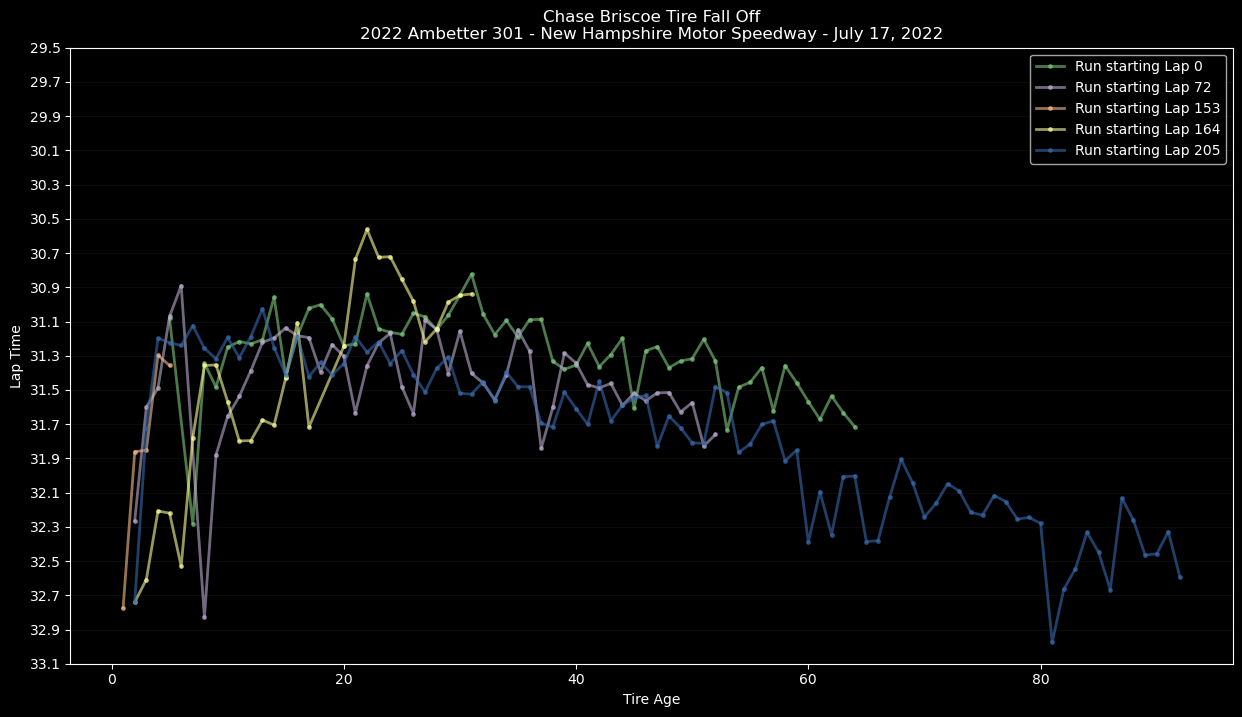

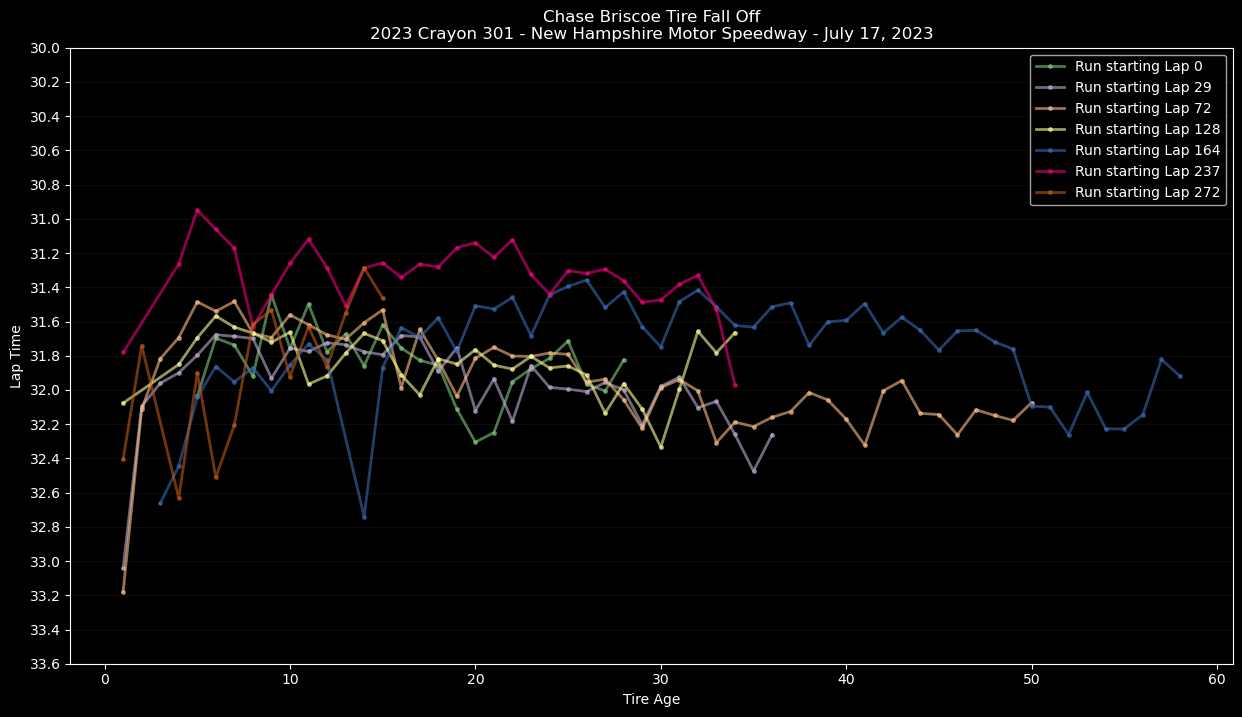

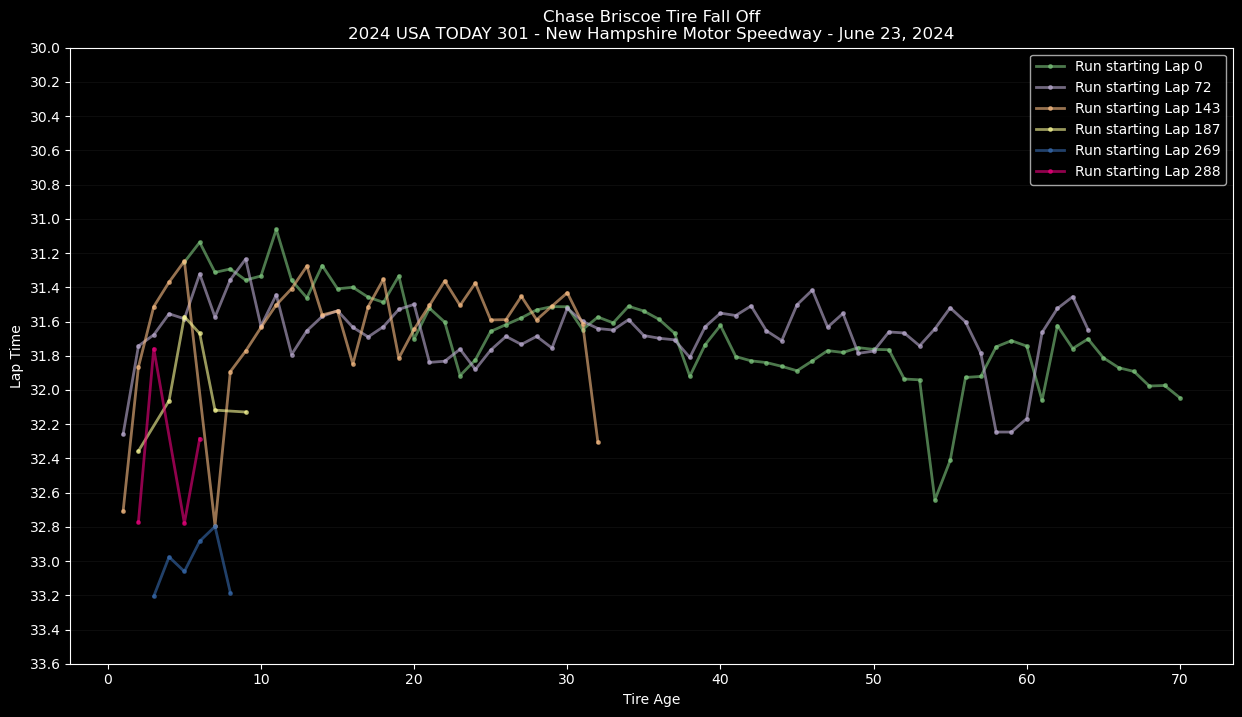

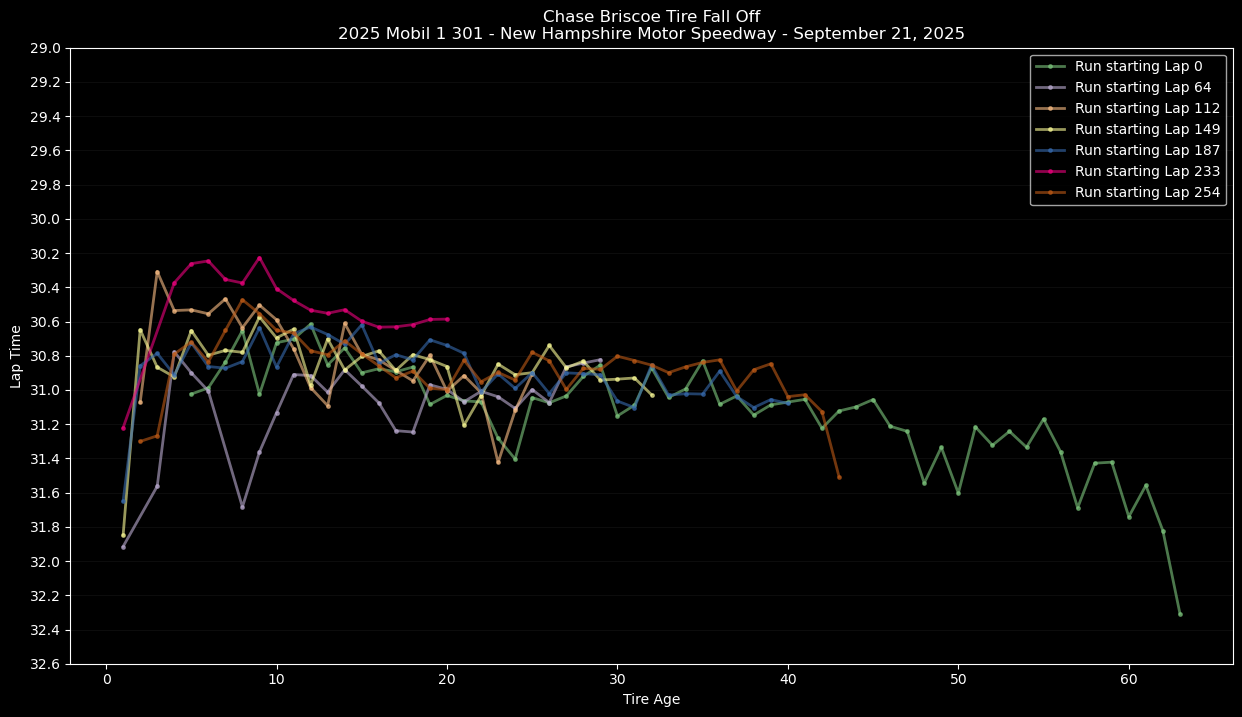

,race_year,race_name,race_date,avg_laptime,median_laptime,finish_pos
0,2022,Ambetter 301,"July 17, 2022",31.550,31.481,15
1,2023,Crayon 301,"July 17, 2023",31.803,31.815,10
2,2024,USA TODAY 301,"June 23, 2024",31.741,31.742,2
3,2025,Mobil 1 301,"September 21, 2025",30.933,30.905,10


In [20]:
driver_data = analyze_track('New Hampshire Motor Speedway', 'Chase Briscoe')
driver_data